# Exploratory Data Analysis of GlobalGeoTree

## Module and Data Imports

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns


dfAll = pd.read_parquet('GlobalGeoTree-6M\GlobalGeoTree-6M.parquet')

<>:7: SyntaxWarning: invalid escape sequence '\G'
<>:7: SyntaxWarning: invalid escape sequence '\G'
C:\Users\yy21473\AppData\Local\Temp\ipykernel_25316\2059939654.py:7: SyntaxWarning: invalid escape sequence '\G'
  dfAll = pd.read_parquet('GlobalGeoTree-6M\GlobalGeoTree-6M.parquet')


## Missing Data

### Count

In [3]:
dfAll.isnull().sum()

totalNull = np.sum(dfAll.isnull().sum().unique())

print('Total rows with null values:', totalNull)

Total rows with null values: 744561


In [4]:
dfAll.isnull().sum()/dfAll.shape[0]*100

sample_id                0.001383
longitude                0.001383
latitude                 0.001383
elevation                2.572162
slope                    2.572162
aspect                   2.572162
soil_moisture_0_5cm      7.436313
soil_moisture_5_15cm     7.436313
soil_moisture_15_30cm    7.436313
bio01                    1.961733
bio02                    1.961733
bio03                    1.961733
bio04                    1.961733
bio05                    1.961733
bio06                    1.961733
bio07                    1.961733
bio08                    1.961733
bio09                    1.961733
bio10                    1.961733
bio11                    1.961733
bio12                    1.961733
bio13                    1.961733
bio14                    1.961733
bio15                    1.961733
bio16                    1.961733
bio17                    1.961733
bio18                    1.961733
bio19                    1.961733
level0                   0.000000
level1_family 

### Drop

In [2]:
df = dfAll.dropna()

print(dfAll.shape[0] - df.shape[0], 'rows removed')
df.shape

627791 rows removed


(5591608, 32)

### Save

In [ ]:
df.to_parquet("GlobalGeoTree-6M/GlobalGeoTreeNoMissing.parquet", index=False)

In [3]:
import pandas as pd
df = pd.read_parquet('GlobalGeoTree-6M/GlobalGeoTreeNoMissing.parquet')

# Histograms

In [13]:
type(df['latitude'][0])

numpy.float64

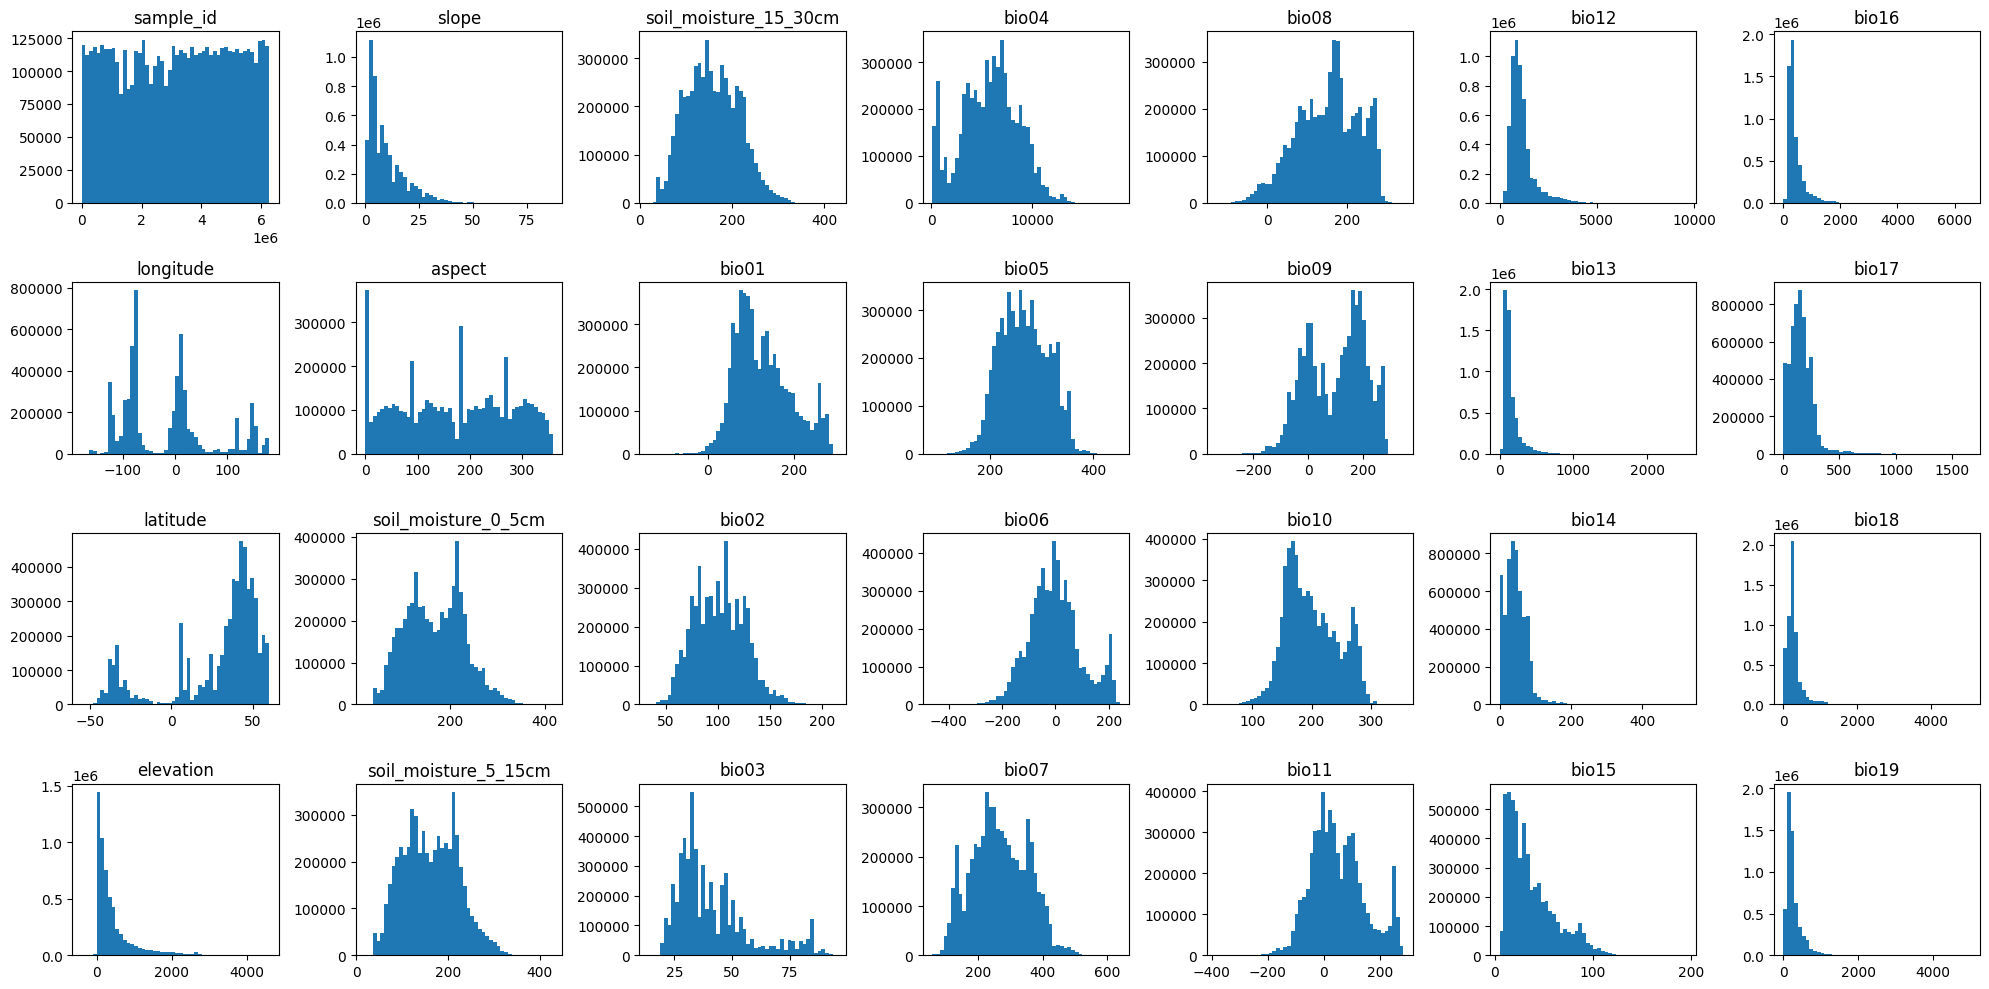

In [10]:
columns = df.columns
figHist, axHist = plt.subplots(nrows = 4, ncols = 7, figsize = (20, 10))

for i in range(df.shape[1]-4):
    a = i % 4
    b = i // 4

    if type(df[columns[i]][0]) == np.float64:
        data = df[columns[i]].to_numpy(dtype='float32')

        axHist[a, b].hist(data, bins = 50)
    else:
        data = df[columns[i]].value_counts()
        axHist[a, b].bar(data.index, data.values)

    axHist[a, b].set_title(columns[i])

figHist.tight_layout()



- Bioclimate variables are from [here](https://www.worldclim.org/data/bioclim.html)
    - 1 - 11 relate to temperature
    - 12 - 19 relate to precipitation
- Aspect is a bearing of the direction the slope faces
    - potential systematic error in data collection
- a lot of log normalish data

# Geographic Plots

In [22]:
print(df.columns)

Index(['sample_id', 'longitude', 'latitude', 'elevation', 'slope', 'aspect',
       'soil_moisture_0_5cm', 'soil_moisture_5_15cm', 'soil_moisture_15_30cm',
       'bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08',
       'bio09', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16',
       'bio17', 'bio18', 'bio19', 'level0', 'level1_family', 'level2_genus',
       'level3_species'],
      dtype='object')


(-180.0, 180.0)

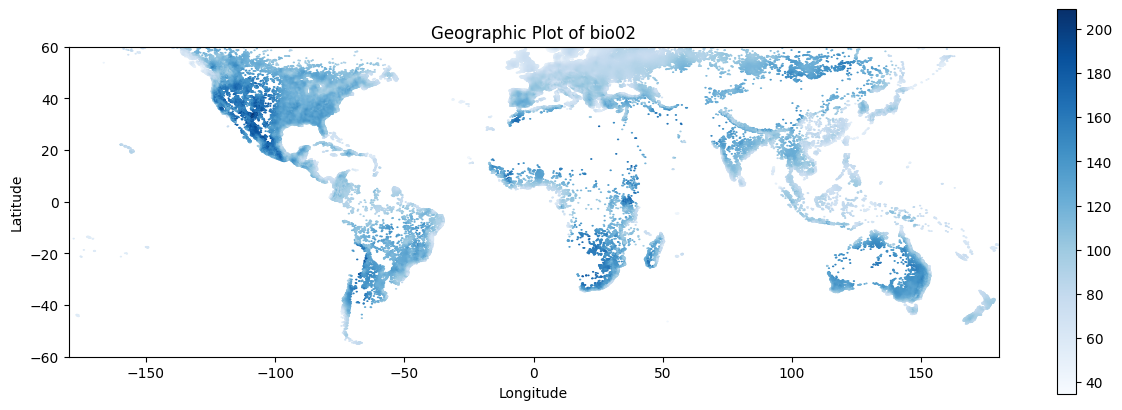

In [11]:
figGeo, axGeo = plt.subplots(figsize=(15, 5))

chosenVariable = 'bio02'

hb = axGeo.hexbin(
    df["longitude"], 
    df["latitude"], 
    C=df[chosenVariable],    # optional: color by longitude
    reduce_C_function=np.mean,
    gridsize=1000,
    cmap="Blues"
)

figGeo.colorbar(hb, ax=axGeo)
axGeo.set_aspect("equal")

axGeo.set_xlabel('Longitude')
axGeo.set_ylabel('Latitude')
axGeo.set_title('Geographic Plot of '+ chosenVariable)

axGeo.set_ylim(-60, 60)
axGeo.set_xlim(-180, 180)

# Pairs Plots

## Temperature Variables

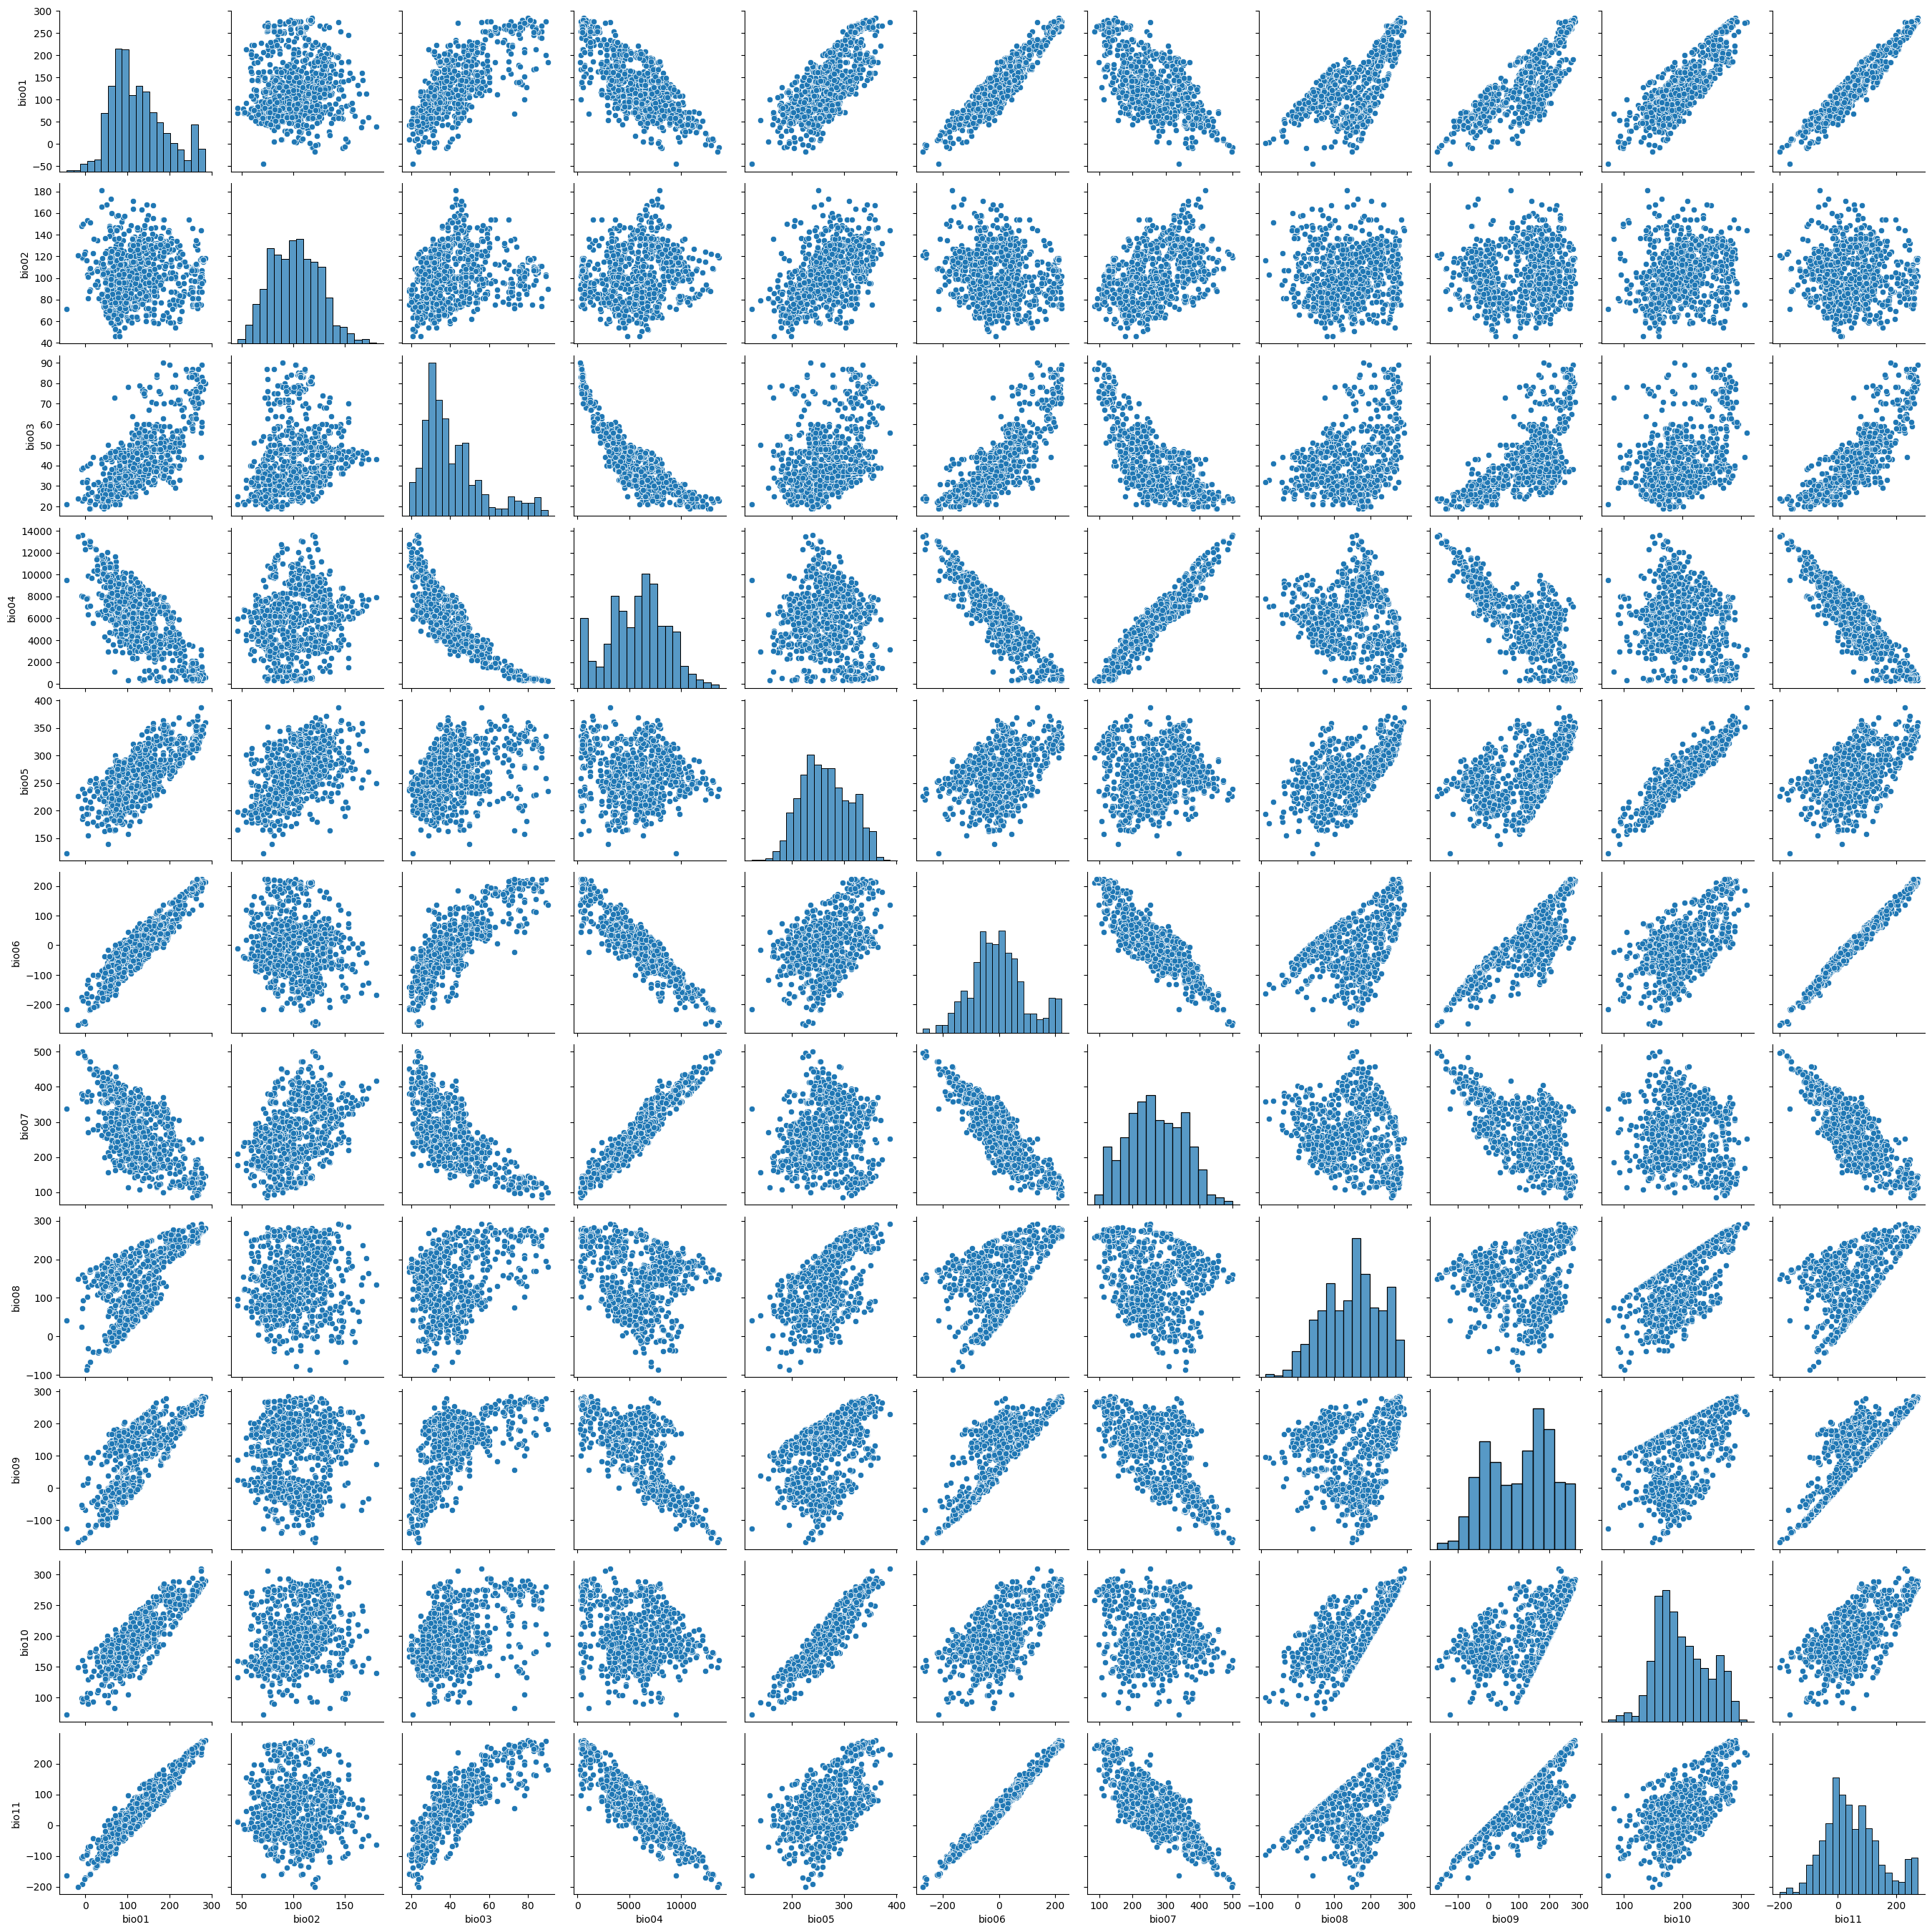

In [ ]:
dfTemp = df[['bio01', 'bio02', 'bio03', 'bio04', 'bio05', 'bio06', 'bio07', 'bio08', 'bio09', 'bio10', 'bio11']]

dfTempSample = dfTemp.sample(1000)

sns.pairplot(dfTempSample)

## Preciptation Variables

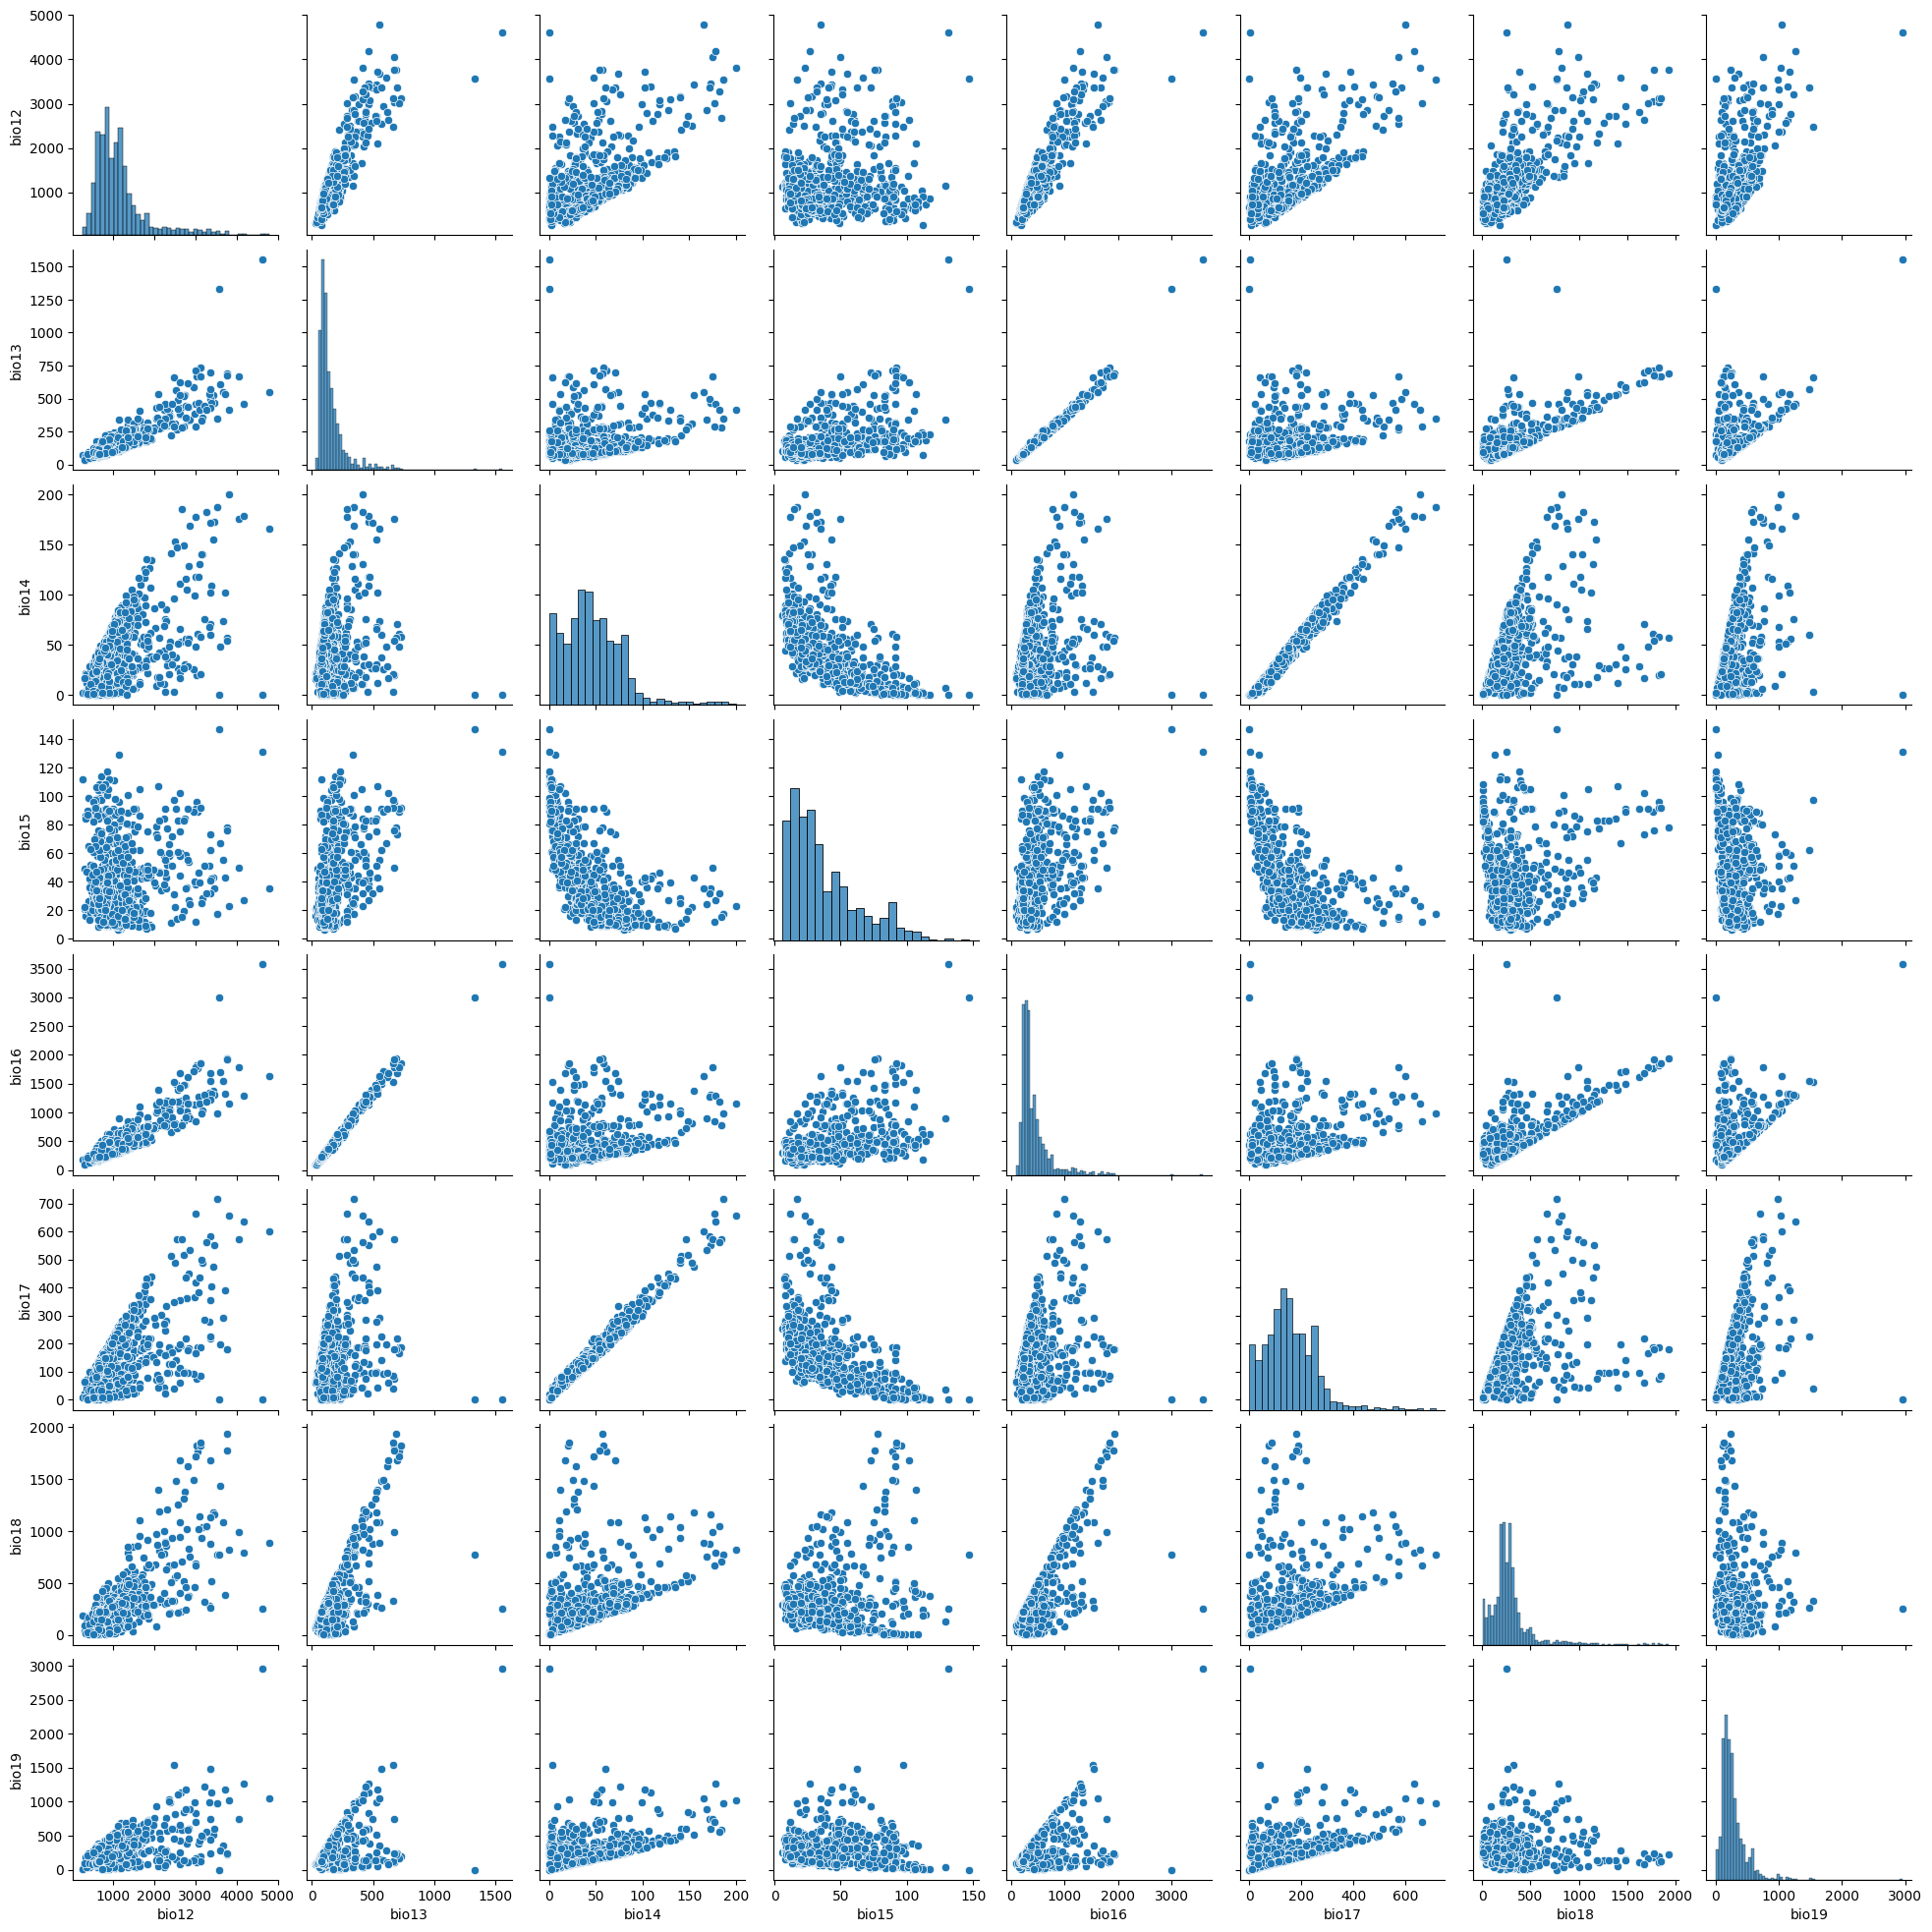

In [10]:
dfPrep = df[['bio12','bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']]

dfPrepSample = dfPrep.sample(1000)

sns.pairplot(dfPrepSample)

## Soil Moisture
- Heavily correlated

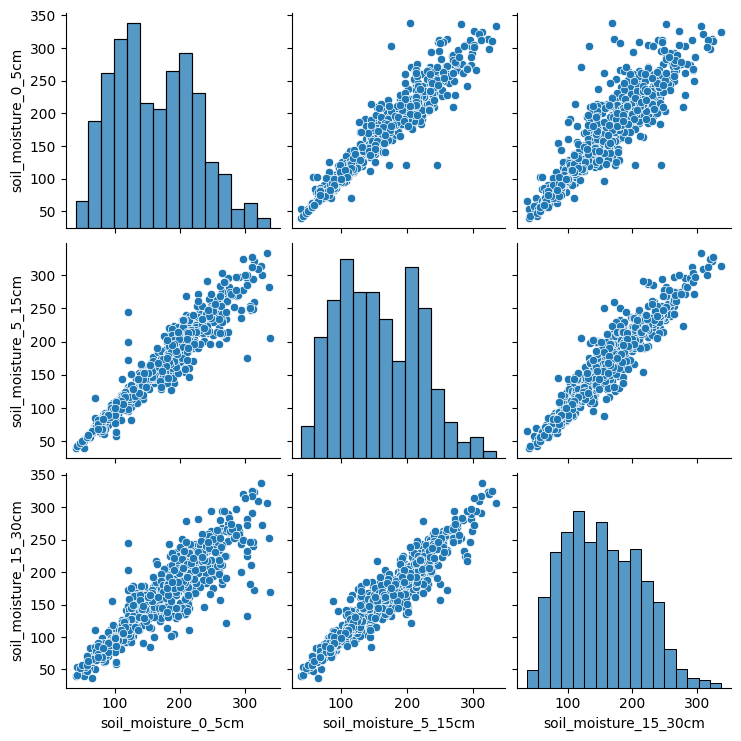

In [13]:
dfSoil = df[['soil_moisture_0_5cm', 'soil_moisture_5_15cm', 'soil_moisture_15_30cm']]

dfSoilSample = dfSoil.sample(1000)

sns.pairplot(dfSoilSample)

## Geographic Variables

- Little association

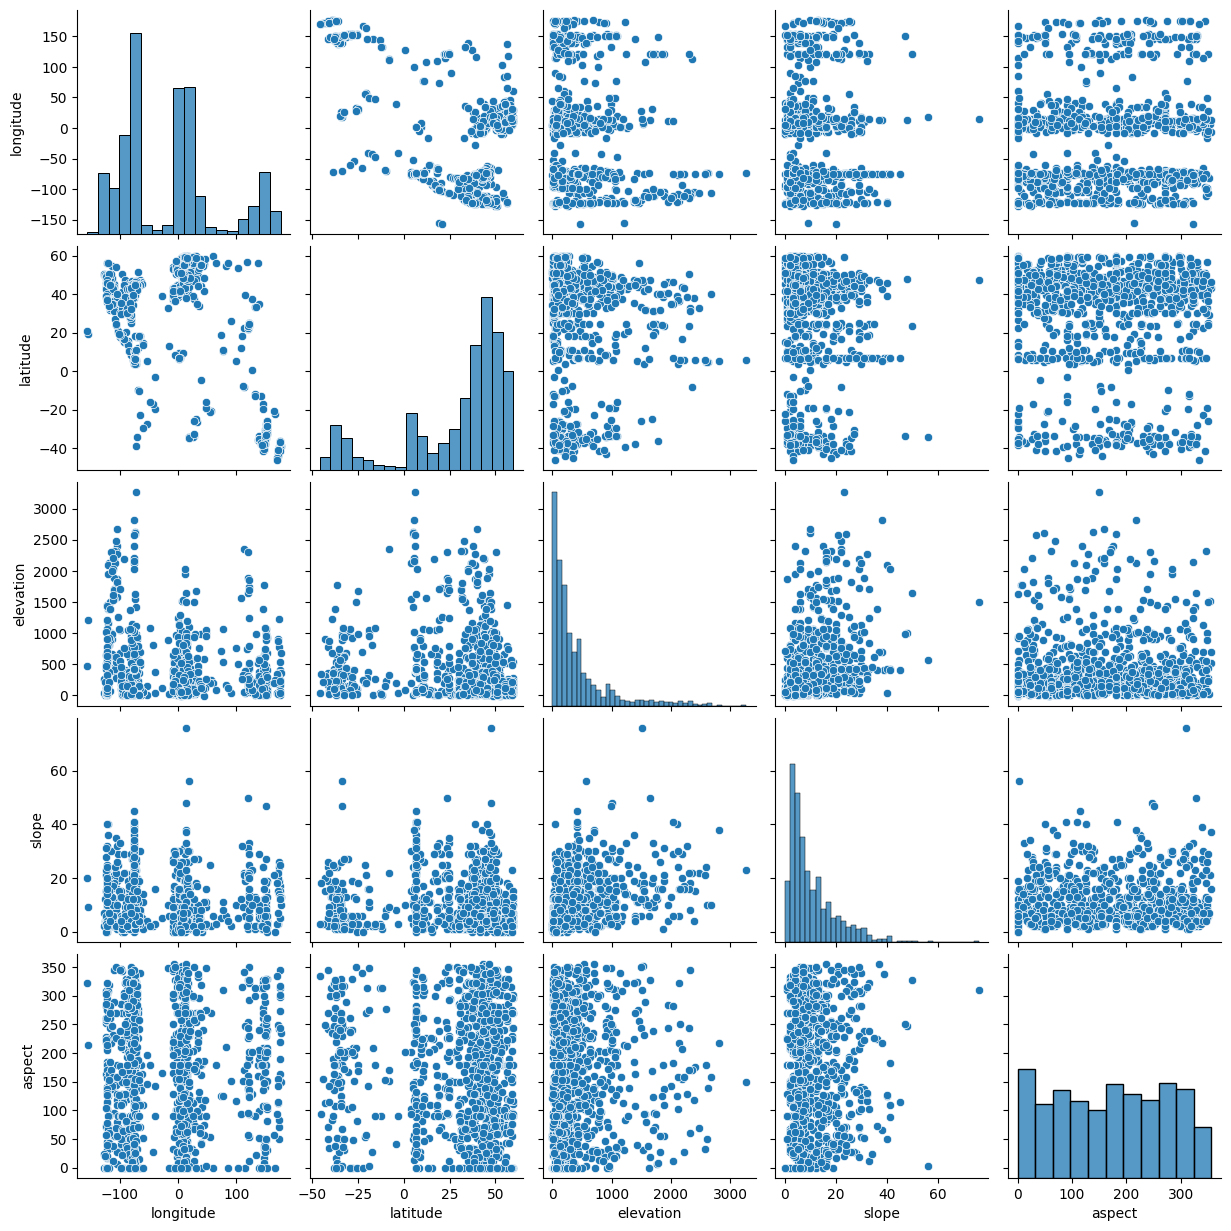

In [14]:
dfGeo = df[['longitude', 'latitude', 'elevation', 'slope', 'aspect']]

dfGeoSample = dfGeo.sample(1000)

sns.pairplot(dfGeoSample)